## Part 1: Random Walk Metropolis Algorithm

This notebook implements the **Random Walk Metropolis** algorithm (a special case of Metropolis-Hastings) to sample from the Laplace distribution:

$$f(x) = \frac{1}{2}\,e^{-|x|}, \qquad x \in \mathbb{R}$$

We start by importing the required Python libraries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import laplace

## Part 1(a): Sampling and Visual Diagnostics

The **Random Walk Metropolis** algorithm works as follows.

**Step 1.** Choose an initial value $x_0$, a positive integer $N$, and a positive real $s$.

**Step 2.** For $i = 1, \ldots, N$:
- Draw a proposal $x^* \sim \mathcal{N}(x_{i-1},\, s^2)$.
- Compute the log-acceptance ratio (safer numerically than the raw ratio):
  $$\log r(x^*, x_{i-1}) = \log f(x^*) - \log f(x_{i-1}) = -|x^*| + |x_{i-1}|$$
- Draw $u \sim \text{Uniform}(0,1)$.
- If $\log u < \log r$, set $x_i = x^*$; otherwise set $x_i = x_{i-1}$.

The function below returns the **full chain** $(x_0, x_1, \ldots, x_N)$ — a Python list of $N+1$ elements.

In [ ]:
def target_log_pdf(x):
    """Log of the Laplace(0,1) target: log f(x) = -log(2) - |x|."""
    return -np.log(2) - np.abs(x)


def metropolis_rw(N=10000, s=1, x0=0):
    """
    Random Walk Metropolis algorithm targeting f(x) = 0.5 * exp(-|x|).

    Parameters
    ----------
    N  : int   Number of MCMC steps.
    s  : float Standard deviation of the Gaussian proposal.
    x0 : float Initial value.

    Returns
    -------
    x : ndarray, shape (N+1,)
        The full chain [x_0, x_1, ..., x_N].  Contains N+1 elements.
    """
    x = np.zeros(N + 1)   # N+1 elements: x_0, x_1, ..., x_N
    x[0] = x0

    for i in range(1, N + 1):
        proposal = np.random.normal(x[i - 1], s)

        # Log-acceptance ratio (avoids numerical errors from raw ratio)
        log_r = target_log_pdf(proposal) - target_log_pdf(x[i - 1])

        if np.log(np.random.rand()) < log_r:
            x[i] = proposal
        else:
            x[i] = x[i - 1]

    return x   # x_0, x_1, ..., x_N  =>  N+1 values total

### Running the Chain

We run the algorithm with $N = 10000$, $s = 1$, $x_0 = 0$.
The returned array has $N + 1 = 10001$ elements.
We use the **generated samples** $(x_1, \ldots, x_N)$ — i.e. we discard the initial seed $x_0$ — for all downstream analysis.

In [ ]:
np.random.seed(42)                        # for reproducibility
chain = metropolis_rw(N=10000, s=1, x0=0)

# Samples are x_1 ... x_N  (exclude the initial value x_0)
samples = chain[1:]                       # 10 000 values

print(f"Full chain length  (x_0 to x_N): {len(chain)}   [should be 10 001]")
print(f"Samples used       (x_1 to x_N): {len(samples)} [should be 10 000]")

Full chain length  (x_0 to x_N): 10001   [should be 10 001]
Samples used       (x_1 to x_N): 10000 [should be 10 000]


### Visualisation: Histogram + KDE + True Laplace PDF

All three elements are overlaid in a **single figure**:

| Element | Role |
|---------|------|
| Histogram (blue) | Non-parametric density estimate from the MCMC samples |
| KDE (red) | Smooth kernel density estimate |
| True PDF (black dashed) | Theoretical Laplace(0,1) density — the sampling target |

Close agreement between all three is evidence that the sampler has converged.

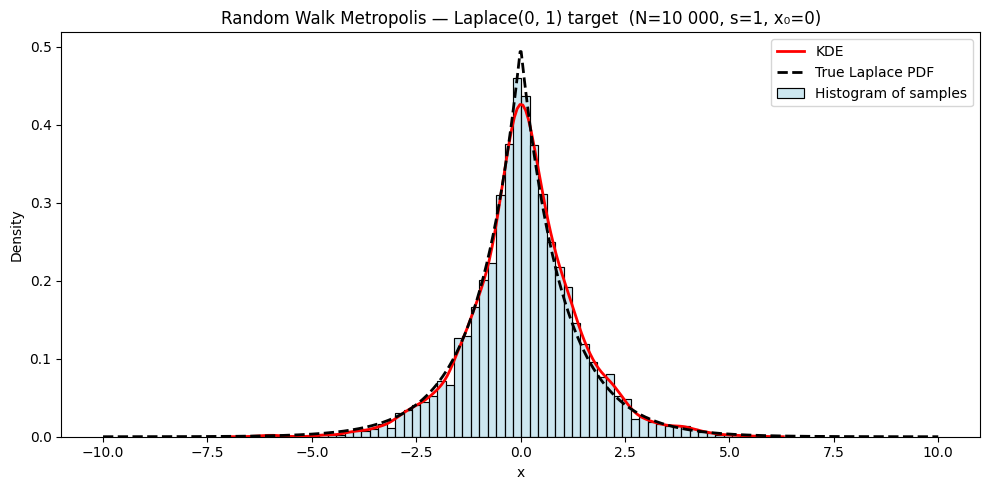

In [ ]:
xs = np.linspace(-10, 10, 800)

plt.figure(figsize=(10, 5))

# 1. Histogram
sns.histplot(samples, bins=60, stat="density",
             color="lightblue", alpha=0.6, label="Histogram of samples")

# 2. KDE
sns.kdeplot(samples, color="red", linewidth=2, label="KDE")

# 3. True Laplace PDF
plt.plot(xs, laplace.pdf(xs, loc=0, scale=1),
         'k--', linewidth=2, label="True Laplace PDF")

plt.title("Random Walk Metropolis — Laplace(0, 1) target  "
          "(N=10 000, s=1, x\u2080=0)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

### Monte Carlo Estimates of Mean and Standard Deviation

The **sample mean** and **sample standard deviation** of $(x_1, \ldots, x_N)$ are Monte Carlo estimates of the true quantities.  
For the Laplace(0, 1) distribution the true mean is $0$ and the true standard deviation is $\sqrt{2} \approx 1.4142$.

In [ ]:
sample_mean = np.mean(samples)
sample_std  = np.std(samples)

print(f"Sample mean               : {sample_mean:.6f}")
print(f"Sample standard deviation : {sample_std:.6f}")
print(f"(True mean = 0,  true std = {np.sqrt(2):.6f})")

Sample mean               : 0.079114
Sample standard deviation : 1.315996
(True mean = 0,  true std = 1.414214)


## Part 1(b): Gelman–Rubin $\hat{R}$ Diagnostic

The **Gelman–Rubin** convergence diagnostic uses multiple chains started from different initial values.  
Denote the $J$ chains as $\{x_i^{(j)}\}_{i=0}^{N}$, $j = 1, \ldots, J$.

**Within-chain mean and variance** for chain $j$ (using $x_1^{(j)}$ to $x_N^{(j)}$):

$$M_j = \frac{1}{N}\sum_{i=1}^{N} x_i^{(j)}, \qquad
V_j = \frac{1}{N}\sum_{i=1}^{N}\bigl(x_i^{(j)} - M_j\bigr)^2$$

**Overall quantities:**

$$W = \frac{1}{J}\sum_{j=1}^{J} V_j, \qquad
M   = \frac{1}{J}\sum_{j=1}^{J} M_j, \qquad
B   = \frac{1}{J}\sum_{j=1}^{J}(M_j - M)^2$$

**Diagnostic:**

$$\hat{R} = \sqrt{\frac{B + W}{W}}$$

$\hat{R}$ close to 1 indicates convergence; the conventional threshold is $\hat{R} < 1.05$.

In [ ]:
def compute_Rhat(chains):
    """
    Gelman-Rubin R-hat statistic.

    Parameters
    ----------
    chains : list of ndarrays, each of shape (N+1,)  [x_0, x_1, ..., x_N]

    Returns
    -------
    Rhat : float
    """
    J = len(chains)

    # Use x_1 ... x_N only (discard x_0 from each chain)
    spc = [chain[1:] for chain in chains]

    Mj = np.array([np.mean(s) for s in spc])       # within-chain means
    # V_j uses 1/N  => population variance  (ddof=0)
    Vj = np.array([np.var(s, ddof=0) for s in spc])

    W = np.mean(Vj)                  # overall within-chain variance  (1/J * sum Vj)
    M = np.mean(Mj)                  # overall mean                   (1/J * sum Mj)
    B = np.mean((Mj - M) ** 2)      # between-chain variance         (1/J * sum (Mj-M)^2)

    Rhat = np.sqrt((B + W) / W)
    return Rhat


def run_chains(N=2000, s=0.001, J=4):
    """
    Run J independent chains from dispersed starting points and return R-hat.

    Starting points are fixed at [-5, 0, 5, 10] to ensure diversity.
    """
    starting_points = [-5, 0, 5, 10]
    chains = [metropolis_rw(N=N, s=s, x0=starting_points[j]) for j in range(J)]
    return compute_Rhat(chains)

### R̂ for N = 2000, s = 0.001, J = 4

With $s = 0.001$ the Gaussian proposal is extremely narrow — almost every proposal is accepted, but the chain barely moves from its starting point.  
Because the four chains start at very different locations ($-5, 0, 5, 10$) and fail to mix within $N = 2000$ steps, we expect $\hat{R} \gg 1$.

In [ ]:
np.random.seed(0)
rhat_s001 = run_chains(N=2000, s=0.001, J=4)
print(f"R-hat (N=2000, s=0.001, J=4) = {rhat_s001:.4f}")

R-hat (N=2000, s=0.001, J=4) = 337.4536


### R̂ over a Grid of s Values

Keeping $N = 2000$ and $J = 4$ fixed, we evaluate $\hat{R}$ at **1000** equally spaced values of $s$ in $[0.001,\, 1]$.

- **Small $s$**: proposals are tiny; chains barely move $\Rightarrow$ poor mixing $\Rightarrow$ large $\hat{R}$.
- **Larger $s$**: proposals cover more ground; chains mix well $\Rightarrow$ $\hat{R} \to 1$.

In [ ]:
np.random.seed(1)
s_values   = np.linspace(0.001, 1, 1000)          # 1000 s values
Rhat_values = [run_chains(N=2000, s=s, J=4) for s in s_values]

print(f"Computed {len(Rhat_values)} R-hat values.")

Computed 1000 R-hat values.


### Plot: R̂ vs Proposal Standard Deviation s

The dashed red line marks the $\hat{R} = 1.05$ convergence threshold.

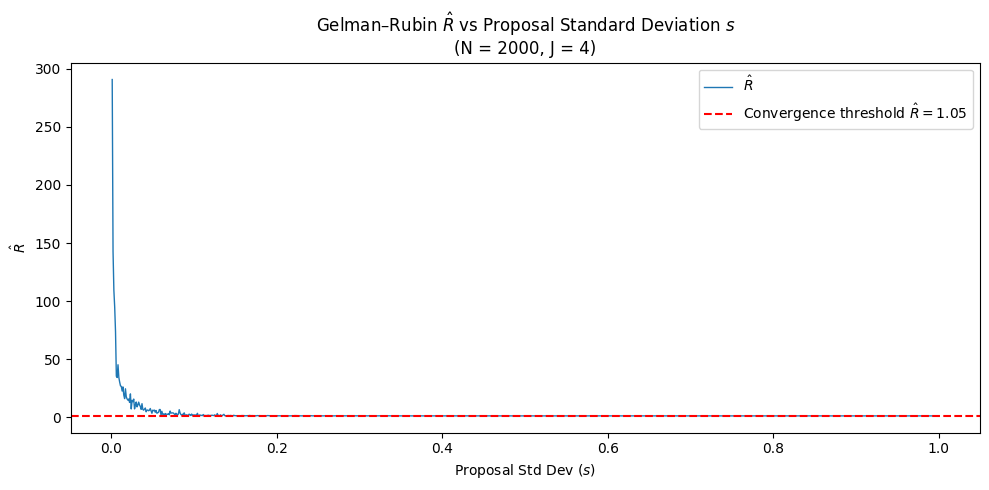

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(s_values, Rhat_values, linewidth=1, label="$\\hat{R}$")
plt.axhline(1.05, color='red', linestyle='--', linewidth=1.5,
            label="Convergence threshold $\\hat{R} = 1.05$")

plt.title("Gelman\u2013Rubin $\\hat{R}$ vs Proposal Standard Deviation $s$\n"
          "(N = 2000, J = 4)")
plt.xlabel("Proposal Std Dev ($s$)")
plt.ylabel("$\\hat{R}$")
plt.legend()
plt.tight_layout()
plt.show()